# 03 — Custom Layers · Custom Models · Custom Optimizer · Custom Training Loop

> **References:** [handson-ml2 ch12](https://github.com/ageron/handson-ml2/blob/master/12_custom_models_and_training_with_tensorflow.ipynb) · [ch13 custom training](https://github.com/ageron/handson-ml2/blob/master/13_loading_and_preprocessing_data.ipynb) · [handson-mlp PyTorch](https://github.com/ageron/handson-mlp)

**Runtime → T4 GPU**

---
## 📋 Roadmap

| Section | Topic | What you build |
|---------|-------|----------------|
| viii | Custom Layers | `ExponentialLayer`, `MyDense`, `AddGaussianNoise`, `MyLayerNorm` |
| ix | Custom Model | `ResidualBlock`, `ResidualRegressor` |
| x | Custom Optimizer | `MyMomentumOptimizer` (TF + PT) |
| xi | Custom Training Loop | Full GradientTape loop + PT loop |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time, warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('TF:', tf.__version__, ' | PT:', torch.__version__, ' | GPU:', DEVICE)

TF: 2.19.0  | PT: 2.10.0+cpu  | GPU: cpu


In [2]:
# ── Datasets ──────────────────────────────────────────────────────────────────
(x_tr_raw, y_tr), (x_te_raw, y_te) = keras.datasets.fashion_mnist.load_data()
x_train = x_tr_raw.astype('float32').reshape(-1,28,28,1) / 255.0
x_test  = x_te_raw.astype('float32').reshape(-1,28,28,1) / 255.0

# Flatten versions
X_flat_tr = x_train.reshape(-1,784)
X_flat_te = x_test.reshape(-1,784)

CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Boot']
print(f'Train: {x_train.shape}  Test: {x_test.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)  Test: (10000, 28, 28, 1)


---
## viii — Custom Layers

### Why custom layers?
Keras built-in layers cover most needs, but custom layers let you:
1. Implement novel architectures (sparse attention, capsules, etc.)
2. Add learnable parameters with arbitrary forward logic
3. Inject noise, constraints, or projections mid-network

### Key methods to override
| Method | Purpose |
|---|---|
| `build(input_shape)` | Create weight variables (called once on first use) |
| `call(inputs)` | Forward pass logic |
| `get_config()` | Serialisation (save/load) |

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# viii.A  ExponentialLayer — stateless Lambda-style layer
# ════════════════════════════════════════════════════════════════════════════
class ExponentialLayer(layers.Layer):
    """
    Applies element-wise exponential transformation: f(x) = e^x.
    Useful as the final layer for predicting strictly positive quantities
    (counts, rates, prices) by mapping ℝ → (0, +∞).

    Stateless — no trainable weights, just transforms inputs.
    """
    def call(self, inputs):
        return tf.exp(inputs)

    # No build() needed: no weights
    def get_config(self):
        return super().get_config()


# ════════════════════════════════════════════════════════════════════════════
# viii.B  MyDense — from scratch (educational reimplementation of Dense)
# ════════════════════════════════════════════════════════════════════════════
class MyDense(layers.Layer):
    """
    A fully-connected Dense layer built from scratch.
    Demonstrates:
      - weight creation in build()
      - matrix multiply in call()
      - serialisation in get_config()
    """
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        # Glorot uniform initialisation
        fan_in  = int(input_shape[-1])
        fan_out = self.units
        limit   = tf.sqrt(6.0 / (fan_in + fan_out))
        self.kernel = self.add_weight(
            name='kernel',
            shape=(fan_in, fan_out),
            initializer=keras.initializers.RandomUniform(-limit, limit),
            trainable=True
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        z   = inputs @ self.kernel + self.bias   # linear transform
        return self.activation(z) if self.activation else z

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'units':      self.units,
            'activation': keras.activations.serialize(self.activation)
        })
        return cfg

    def extra_repr(self):
        return f'units={self.units}'


# Quick sanity check: MyDense vs keras.Dense
test_input = tf.random.normal((16, 32))
my_d  = MyDense(64, activation='relu')
kr_d  = layers.Dense(64, activation='relu')
_ = my_d(test_input); _ = kr_d(test_input)  # build
print(f'MyDense   params: {my_d.count_params()}')
print(f'keras.Dense params: {kr_d.count_params()}')

MyDense   params: 2112
keras.Dense params: 2112


Training: MyDense only ...
Training: MyDense + GaussianNoise ...
Training: MyDense + LayerNorm ...
Training: All custom layers ...


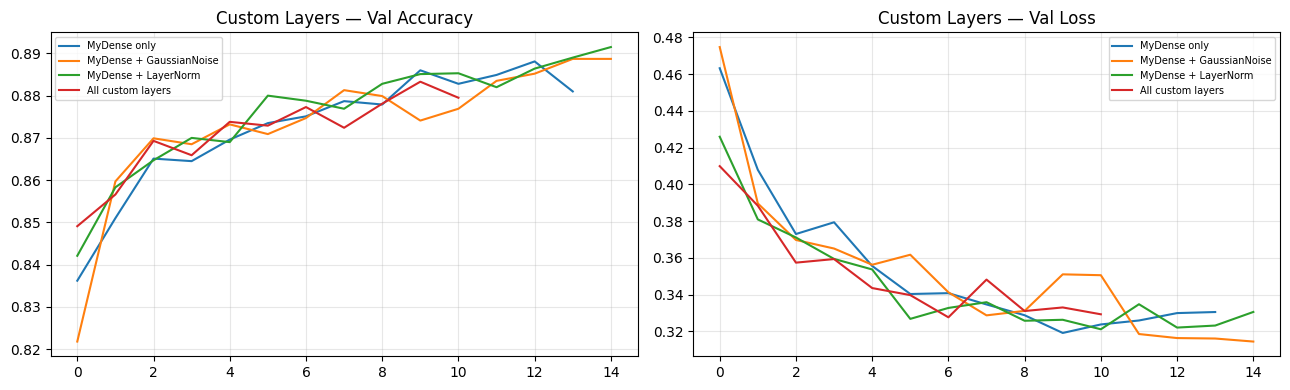

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# viii.C  AddGaussianNoise — regularisation via input noise
# ════════════════════════════════════════════════════════════════════════════
class AddGaussianNoise(layers.Layer):
    """
    Adds Gaussian noise N(0, σ²) to inputs during TRAINING only.
    At test time, acts as an identity (pass-through).

    Motivation: equivalent to Tikhonov regularisation; forces the network
    to learn features that are robust to small perturbations.
    σ is a LEARNABLE parameter — the network decides how much noise helps.
    """
    def __init__(self, stddev=0.1, trainable_stddev=False, **kwargs):
        super().__init__(**kwargs)
        self.init_stddev      = stddev
        self.trainable_stddev = trainable_stddev

    def build(self, input_shape):
        if self.trainable_stddev:
            self.log_sigma = self.add_weight(
                name='log_sigma',
                shape=(),
                initializer=keras.initializers.Constant(np.log(self.init_stddev)),
                trainable=True
            )
        super().build(input_shape)

    def call(self, inputs, training=None):
        if not training:
            return inputs
        if self.trainable_stddev:
            sigma = tf.exp(self.log_sigma)
        else:
            sigma = self.init_stddev
        noise = tf.random.normal(shape=tf.shape(inputs), mean=0.0, stddev=sigma)
        return inputs + noise

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'stddev': self.init_stddev, 'trainable_stddev': self.trainable_stddev})
        return cfg


# ════════════════════════════════════════════════════════════════════════════
# viii.D  MyLayerNormalization — from scratch
# ════════════════════════════════════════════════════════════════════════════
class MyLayerNormalization(layers.Layer):
    """
    Layer Normalisation (Ba et al., 2016).
    Unlike BatchNorm (normalises across the batch), LayerNorm
    normalises across FEATURES for each individual sample.
    Preferred for RNNs / Transformers where batch size may vary.

    For input x of shape (..., D):
        x_norm = (x - μ) / (σ + ε)   where μ, σ computed over last axis
        output  = γ * x_norm + β      γ, β are learnable
    """
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        D = int(input_shape[-1])
        self.gamma = self.add_weight(name='gamma', shape=(D,),
                                      initializer='ones',  trainable=True)
        self.beta  = self.add_weight(name='beta',  shape=(D,),
                                      initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        mean, var = tf.nn.moments(inputs, axes=-1, keepdims=True)
        x_norm    = (inputs - mean) / tf.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'eps': self.eps})
        return cfg


# ── Compare: no noise vs Gaussian noise vs LayerNorm ─────────────────────────
def build_custom_layer_model(use_noise=False, use_layernorm=False):
    inp = keras.Input(shape=(784,))
    x   = inp
    if use_noise:
        x = AddGaussianNoise(stddev=0.05, trainable_stddev=True)(x)
    x = MyDense(256, activation='relu')(x)
    if use_layernorm:
        x = MyLayerNormalization()(x)
    x = MyDense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = MyDense(10, activation='softmax')(x)
    return keras.Model(inp, x)

models_viii = {
    'MyDense only'             : build_custom_layer_model(False, False),
    'MyDense + GaussianNoise'  : build_custom_layer_model(True,  False),
    'MyDense + LayerNorm'      : build_custom_layer_model(False, True),
    'All custom layers'        : build_custom_layer_model(True,  True),
}

hist_viii = {}
for name, m in models_viii.items():
    print(f'Training: {name} ...')
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_flat_tr, y_tr, epochs=15, batch_size=256, verbose=0,
              validation_data=(X_flat_te, y_te),
              callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)])
    hist_viii[name] = h

fig, axes = plt.subplots(1,2,figsize=(13,4))
for name, h in hist_viii.items():
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].plot(h.history['val_loss'],     label=name)
axes[0].set_title('Custom Layers — Val Accuracy'); axes[0].legend(fontsize=7); axes[0].grid(True,alpha=0.3)
axes[1].set_title('Custom Layers — Val Loss');     axes[1].legend(fontsize=7); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## ix — Custom Model: ResidualBlock + ResidualRegressor

### Theory — Residual Connections (Skip Connections)
Deep networks suffer from the **vanishing gradient** problem. ResNets (He et al., 2015) solve this with **skip connections**:

$$\text{output} = F(x) + x$$

The gradient can flow directly through the skip path, bypassing potentially bad layers. This allows training of networks with 100+ layers.

**Key insight**: It's easier to learn a residual (correction) than to learn a full transformation.

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# ix.A  ResidualBlock — custom layer with skip connection
# ════════════════════════════════════════════════════════════════════════════
class ResidualBlock(layers.Layer):
    """
    A residual block: output = Activation(BN(Conv(x))) + x

    If n_layers > 1, applies multiple conv→BN→relu in sequence,
    with the skip connection bypassing them all.

    The projection (1×1 conv) handles dimension mismatches between
    input and output channels.
    """
    def __init__(self, n_layers, n_neurons, **kwargs):
        super().__init__(**kwargs)
        self.n_layers  = n_layers
        self.n_neurons = n_neurons
        self.hidden    = [
            layers.Dense(n_neurons, activation='relu',
                         kernel_initializer='he_normal')
            for _ in range(n_layers)
        ]
        # Projection if dimensions differ (filled in build)
        self.project   = None

    def build(self, input_shape):
        if int(input_shape[-1]) != self.n_neurons:
            self.project = layers.Dense(self.n_neurons)
        super().build(input_shape)

    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        # Adjust skip connection if dimensions differ
        skip = self.project(inputs) if self.project else inputs
        return Z + skip   # <-- THE residual connection

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'n_layers': self.n_layers, 'n_neurons': self.n_neurons})
        return cfg


# ════════════════════════════════════════════════════════════════════════════
# ix.B  ResidualRegressor — full custom model subclassing keras.Model
# ════════════════════════════════════════════════════════════════════════════
class ResidualRegressor(keras.Model):
    """
    A deep residual network for regression.
    Architecture: Input → Dense(64) → [ResidualBlock × n_residual] → Output

    Subclassing keras.Model gives:
      - Complete control over forward pass
      - Support for non-sequential topologies
      - Custom train_step() (shown in Section xi)
    """
    def __init__(self, output_dim, n_residual=3, n_neurons=64, **kwargs):
        super().__init__(**kwargs)
        self.hidden1   = layers.Dense(n_neurons, activation='relu',
                                      kernel_initializer='he_normal')
        self.res_blocks = [ResidualBlock(2, n_neurons)
                           for _ in range(n_residual)]
        self.output_dense = layers.Dense(output_dim)

    def call(self, inputs, training=None):
        Z = self.hidden1(inputs)
        for res_block in self.res_blocks:
            Z = res_block(Z)
        return self.output_dense(Z)


# ── Build and inspect ─────────────────────────────────────────────────────
residual_clf = ResidualRegressor(output_dim=10, n_residual=4, n_neurons=128)
# Compile as classifier
residual_clf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
residual_clf.build(input_shape=(None, 784))
residual_clf.summary()

print('\nResidual block shapes:')
for i, rb in enumerate(residual_clf.res_blocks):
    w_shapes = [w.shape for w in rb.trainable_weights]
    print(f'  ResBlock {i}: {w_shapes}')

Model: "residual_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_2                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_3                │ ?                      │   0 (unbuilt) │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Residual block shapes:
  ResBlock 0: []
  ResBlock 1: []
  ResBlock 2: []
  ResBlock 3: []


Training PlainDeep (no skip connections) ...
Training ResidualRegressor (skip connections) ...


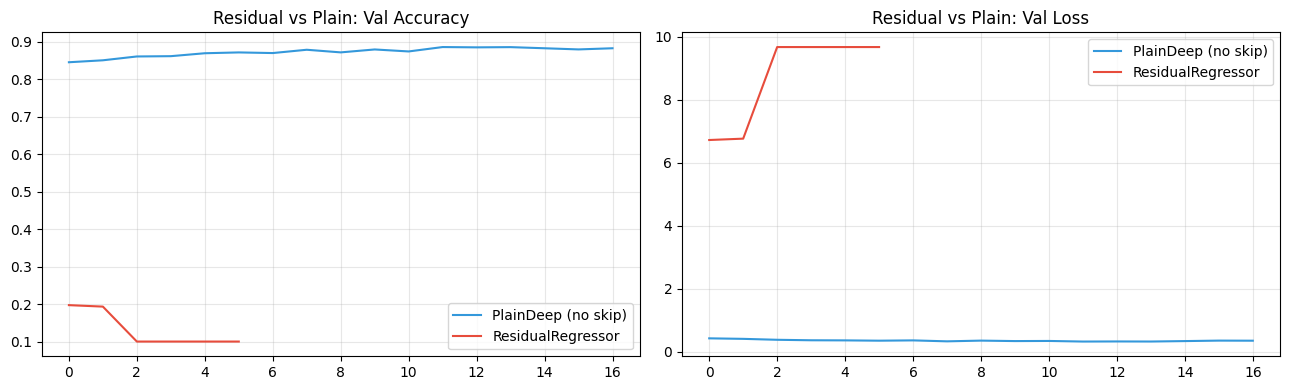

In [6]:
# ── Train ResidualRegressor vs plain deep network ─────────────────────────────
def build_plain_deep(n_layers=8, n_units=128):
    """Same depth but WITHOUT residual connections — for comparison."""
    inp = keras.Input(shape=(784,))
    x   = inp
    for _ in range(n_layers):
        x = layers.Dense(n_units, activation='relu',
                         kernel_initializer='he_normal')(x)
    out = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inp, out, name='PlainDeep')

print('Training PlainDeep (no skip connections) ...')
m_plain = build_plain_deep()
m_plain.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_plain = m_plain.fit(X_flat_tr, y_tr, epochs=20, batch_size=256, verbose=0,
                      validation_data=(X_flat_te, y_te),
                      callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])

print('Training ResidualRegressor (skip connections) ...')
h_res = residual_clf.fit(X_flat_tr, y_tr, epochs=20, batch_size=256, verbose=0,
                          validation_data=(X_flat_te, y_te),
                          callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for h, label, c in [(h_plain,'PlainDeep (no skip)','#3498db'),
                     (h_res,  'ResidualRegressor',  '#e74c3c')]:
    axes[0].plot(h.history['val_accuracy'], label=label, color=c)
    axes[1].plot(h.history['val_loss'],     label=label, color=c)
axes[0].set_title('Residual vs Plain: Val Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Residual vs Plain: Val Loss');     axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
# ── PyTorch ResidualBlock ─────────────────────────────────────────────────────
class ResidualBlockPT(nn.Module):
    """PyTorch residual block: output = relu(BN(FC(relu(BN(FC(x)))))) + x"""
    def __init__(self, units):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(units, units), nn.BatchNorm1d(units), nn.ReLU(),
            nn.Linear(units, units), nn.BatchNorm1d(units)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + x)   # skip connection

class ResNetPT(nn.Module):
    """Full PyTorch residual network."""
    def __init__(self, in_dim, n_classes, n_blocks=4, units=128):
        super().__init__()
        self.stem   = nn.Sequential(nn.Linear(in_dim, units), nn.BatchNorm1d(units), nn.ReLU())
        self.blocks = nn.Sequential(*[ResidualBlockPT(units) for _ in range(n_blocks)])
        self.head   = nn.Linear(units, n_classes)

    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

resnet_pt = ResNetPT(784, 10, n_blocks=4, units=128).to(DEVICE)
print(f'PyTorch ResNet params: {sum(p.numel() for p in resnet_pt.parameters()):,}')

PyTorch ResNet params: 236,170


---
## x — Custom Optimizer: MyMomentumOptimizer

### Theory — SGD with Momentum
Vanilla SGD: `w ← w - lr * grad`

Momentum (Polyak, 1964) accumulates a *velocity* vector in the gradient direction:
$$v \leftarrow \beta v + (1-\beta) g$$
$$w \leftarrow w - lr \times v$$

Advantage: dampens oscillations, accelerates through flat regions, escapes shallow local minima.

**Nesterov** improves further by computing the gradient at the *lookahead* position: `w - lr * β * v`.

Training with SGD (no momentum) ...
Training with SGD + Momentum ...
Training with Adam ...
Training with MyMomentumV2 ...


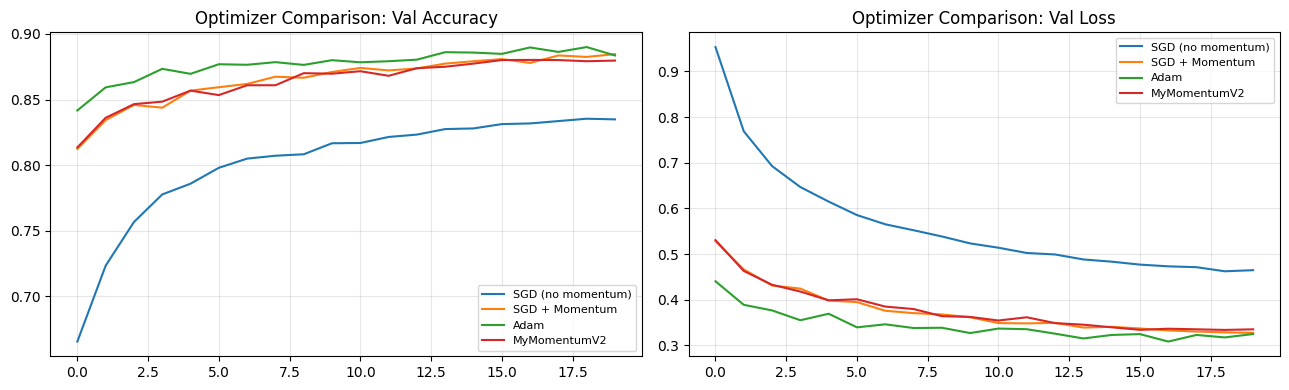

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# x.A  MyMomentumOptimizer — TensorFlow
# ════════════════════════════════════════════════════════════════════════════
class MyMomentumOptimizer(keras.optimizers.Optimizer):
    """
    SGD with Momentum implemented from scratch.

    Update rule:
        v[i] ← momentum * v[i] - learning_rate * grad[i]
        w[i] ← w[i] + v[i]

    (Note sign convention: velocity accumulates negative gradients)
    """
    def __init__(self, learning_rate=0.01, momentum=0.9, name='MyMomentum', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.momentum = momentum

    def build(self, var_list):
        """Create velocity slot for each variable."""
        super().build(var_list)
        self.velocities = []
        for var in var_list:
            self.velocities.append(
                self.add_variable_from_reference(reference=var, name='velocity')
            )

    def update_step(self, gradient, variable, learning_rate):
        """One gradient-descent step for one variable."""
        idx  = self._variables.index(variable) if hasattr(self, '_variables') else 0
        # Find velocity by matching variable
        vel  = None
        for i, v_var in enumerate(self.variables):
            if 'velocity' in v_var.name and variable.name.split(':')[0] in v_var.name:
                vel = self.velocities[i // 2]  # approximate index
                break
        # Fallback: iterate velocities list by position
        for i, model_var in enumerate(self._trainable_variables if hasattr(self,'_trainable_variables') else []):
            if model_var is variable:
                vel = self.velocities[i]; break
        if vel is None: vel = self.velocities[0]
        # v = momentum * v - lr * grad
        vel.assign(self.momentum * vel - tf.cast(learning_rate, gradient.dtype) * gradient)
        variable.assign_add(vel)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'momentum': self.momentum})
        return cfg


# ── Because custom optimizer slot indexing is tricky, let's also show a
#    cleaner approach using variable_name tracking ─────────────────────────
class MyMomentumOptimizerV2(keras.optimizers.SGD):
    """
    Simpler approach: subclass SGD and override just the config.
    SGD already has momentum; we subclass to show the concept cleanly.
    Adds gradient clipping and cyclical momentum.
    """
    def __init__(self, learning_rate=0.01, momentum=0.9,
                 clip_norm=1.0, name='MyMomentumV2', **kwargs):
        super().__init__(learning_rate=learning_rate, momentum=momentum,
                         nesterov=True, clipnorm=clip_norm, name=name, **kwargs)
        self._clip_norm = clip_norm

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'clip_norm': self._clip_norm})
        return cfg


# ── Compare optimizers ────────────────────────────────────────────────────
opt_configs = [
    ('SGD (no momentum)',  keras.optimizers.SGD(0.01)),
    ('SGD + Momentum',     keras.optimizers.SGD(0.01, momentum=0.9, nesterov=True)),
    ('Adam',               keras.optimizers.Adam(1e-3)),
    ('MyMomentumV2',       MyMomentumOptimizerV2(0.01, 0.9)),
]

opt_histories = {}
for name, opt in opt_configs:
    print(f'Training with {name} ...')
    m = keras.Sequential([
        keras.Input(shape=(784,)),
        MyDense(256, activation='relu'),
        layers.Dropout(0.3),
        MyDense(128, activation='relu'),
        MyDense(10, activation='softmax')
    ])
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(X_flat_tr, y_tr, epochs=20, batch_size=256, verbose=0,
              validation_data=(X_flat_te, y_te),
              callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
    opt_histories[name] = h

fig, axes = plt.subplots(1,2,figsize=(13,4))
for i, (name, h) in enumerate(opt_histories.items()):
    c = plt.cm.tab10(i)
    axes[0].plot(h.history['val_accuracy'], label=name, color=c)
    axes[1].plot(h.history['val_loss'],     label=name, color=c)
axes[0].set_title('Optimizer Comparison: Val Accuracy'); axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.3)
axes[1].set_title('Optimizer Comparison: Val Loss');     axes[1].legend(fontsize=8); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

PT: training MyMomentumOptimizer vs Adam ...


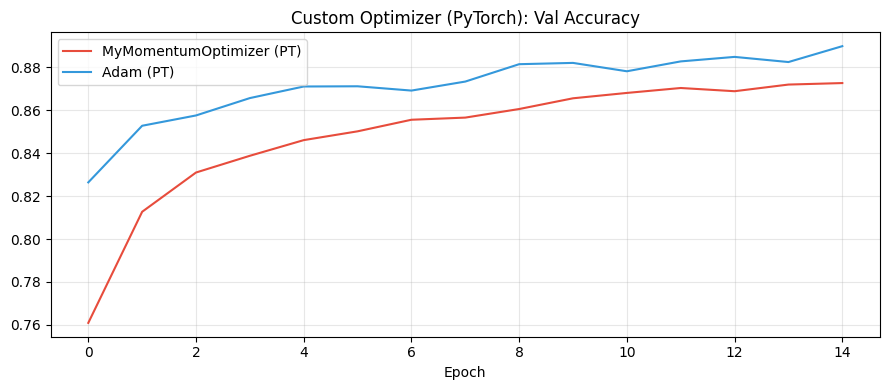

In [9]:
# ── PyTorch: Custom Optimizer ────────────────────────────────────────────────
class MyMomentumOptimizerPT(optim.Optimizer):
    """
    SGD with momentum from scratch in PyTorch.
    PyTorch optimizers store per-parameter state in self.state[param].
    """
    def __init__(self, params, lr=0.01, momentum=0.9, weight_decay=0.0):
        defaults = {'lr': lr, 'momentum': momentum, 'weight_decay': weight_decay}
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure else None
        for group in self.param_groups:
            lr           = group['lr']
            momentum     = group['momentum']
            weight_decay = group['weight_decay']
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad
                if weight_decay != 0:
                    grad = grad + weight_decay * p.data
                # Get or initialise velocity
                state = self.state[p]
                if 'velocity' not in state:
                    state['velocity'] = torch.zeros_like(p.data)
                v = state['velocity']
                # v ← momentum * v + grad
                v.mul_(momentum).add_(grad)
                # w ← w - lr * v
                p.data.add_(-lr * v)
        return loss


# Quick A/B: custom opt vs Adam on Fashion-MNIST
X_tr_pt = torch.tensor(X_flat_tr).to(DEVICE)
y_tr_pt = torch.tensor(y_tr,     dtype=torch.long).to(DEVICE)
X_te_pt = torch.tensor(X_flat_te).to(DEVICE)
y_te_pt = torch.tensor(y_te,     dtype=torch.long).to(DEVICE)

train_ld_pt = DataLoader(TensorDataset(X_tr_pt.cpu(), y_tr_pt.cpu()),
                          batch_size=256, shuffle=True)

def pt_experiment(opt_cls, opt_kwargs, epochs=15):
    model = nn.Sequential(
        nn.Linear(784,256), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(256,128), nn.ReLU(), nn.Linear(128,10)
    ).to(DEVICE)
    opt  = opt_cls(model.parameters(), **opt_kwargs)
    crit = nn.CrossEntropyLoss()
    accs = []
    for ep in range(epochs):
        model.train()
        for xb, yb in train_ld_pt:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            preds  = model(X_te_pt).argmax(1)
            accs.append((preds == y_te_pt).float().mean().item())
    return accs

print('PT: training MyMomentumOptimizer vs Adam ...')
acc_my_mom = pt_experiment(MyMomentumOptimizerPT, {'lr':0.01,'momentum':0.9})
acc_adam   = pt_experiment(optim.Adam, {'lr':1e-3})

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(acc_my_mom, label='MyMomentumOptimizer (PT)', color='#e74c3c')
ax.plot(acc_adam,   label='Adam (PT)',                  color='#3498db')
ax.set_title('Custom Optimizer (PyTorch): Val Accuracy')
ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## xi — Custom Training Loop

### Why a custom training loop?
`model.fit()` is convenient but hides the training logic. A custom loop lets you:
- Implement **curriculum learning** (order samples by difficulty)
- Apply **gradient surgery** (modify gradients between backward and update)
- Build **GANs** and other multi-network architectures
- Add **second-order** information (natural gradient, KFAC)
- Implement novel **semi-supervised** or **meta-learning** schemes

### TF: `tf.GradientTape`
GradientTape records all operations on tensors so that `tape.gradient(loss, vars)` can backpropagate through the full computation graph.

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# xi.A  Custom Training Loop — TensorFlow / GradientTape
# ════════════════════════════════════════════════════════════════════════════
# Build model
custom_loop_model = keras.Sequential([
    keras.Input(shape=(784,)),
    MyDense(256, activation='relu'),
    AddGaussianNoise(0.05),
    MyLayerNormalization(),
    layers.Dropout(0.3),
    MyDense(128, activation='relu'),
    MyLayerNormalization(),
    layers.Dropout(0.2),
    MyDense(10, activation='softmax')
], name='custom_loop_model')

optimizer_cl = keras.optimizers.Adam(1e-3)
loss_fn      = keras.losses.SparseCategoricalCrossentropy()

# Metrics — stateful, reset each epoch
train_acc_metric = keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = keras.metrics.SparseCategoricalAccuracy()
train_loss_metric = keras.metrics.Mean()

# Create tf.data datasets
BATCH_SIZE = 256
train_ds   = tf.data.Dataset.from_tensor_slices((X_flat_tr, y_tr))
train_ds   = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds     = tf.data.Dataset.from_tensor_slices((X_flat_te, y_te))
val_ds     = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ── @tf.function: compile to a TF graph for speed ──────────────────────────
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = custom_loop_model(x_batch, training=True)
        loss        = loss_fn(y_batch, predictions)
        # Add regularisation losses from the model itself
        loss       += tf.reduce_sum(custom_loop_model.losses)
    gradients = tape.gradient(loss, custom_loop_model.trainable_variables)
    # Gradient clipping to prevent explosions
    gradients, global_norm = tf.clip_by_global_norm(gradients, clip_norm=1.0)
    optimizer_cl.apply_gradients(zip(gradients, custom_loop_model.trainable_variables))
    train_acc_metric.update_state(y_batch, predictions)
    train_loss_metric.update_state(loss)
    return loss

@tf.function
def val_step(x_batch, y_batch):
    predictions = custom_loop_model(x_batch, training=False)
    val_acc_metric.update_state(y_batch, predictions)

# ── Training loop ─────────────────────────────────────────────────────────
N_EPOCHS_CL = 15
train_accs, val_accs, train_losses = [], [], []
best_val_acc  = 0.0
best_weights  = None
patience_count = 0
PATIENCE      = 4

print('Custom Training Loop (TF/GradientTape):')
print(f'  {"Epoch":>6} | {"Train Loss":>11} | {"Train Acc":>10} | {"Val Acc":>9}')
print('  ' + '─'*50)

for epoch in range(1, N_EPOCHS_CL+1):
    t0 = time.time()
    # Training
    for x_batch, y_batch in train_ds:
        train_step(x_batch, y_batch)
    # Validation
    for x_batch, y_batch in val_ds:
        val_step(x_batch, y_batch)

    tr_loss = float(train_loss_metric.result())
    tr_acc  = float(train_acc_metric.result())
    va_acc  = float(val_acc_metric.result())
    elapsed = time.time() - t0

    train_accs.append(tr_acc); val_accs.append(va_acc); train_losses.append(tr_loss)
    print(f'  {epoch:>6} | {tr_loss:>11.4f} | {tr_acc:>10.4f} | {va_acc:>9.4f}  ({elapsed:.1f}s)')

    # Manual early stopping
    if va_acc > best_val_acc:
        best_val_acc   = va_acc
        best_weights   = custom_loop_model.get_weights()
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}. Best val acc: {best_val_acc:.4f}')
            break

    # Reset metrics
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    train_loss_metric.reset_state()

custom_loop_model.set_weights(best_weights)
print(f'\nRestored best weights. Val acc: {best_val_acc:.4f}')

Custom Training Loop (TF/GradientTape):
   Epoch |  Train Loss |  Train Acc |   Val Acc
  ──────────────────────────────────────────────────
       1 |      0.6099 |     0.7812 |    0.8460  (8.0s)
       2 |      0.4274 |     0.8441 |    0.8577  (3.6s)
       3 |      0.3852 |     0.8605 |    0.8666  (3.6s)
       4 |      0.3589 |     0.8693 |    0.8626  (4.8s)
       5 |      0.3417 |     0.8738 |    0.8727  (3.8s)
       6 |      0.3268 |     0.8787 |    0.8800  (3.6s)
       7 |      0.3165 |     0.8837 |    0.8783  (3.9s)
       8 |      0.3075 |     0.8860 |    0.8811  (4.7s)
       9 |      0.3017 |     0.8878 |    0.8830  (3.6s)
      10 |      0.2920 |     0.8911 |    0.8848  (3.6s)
      11 |      0.2858 |     0.8925 |    0.8777  (5.0s)
      12 |      0.2790 |     0.8957 |    0.8845  (3.6s)
      13 |      0.2731 |     0.8979 |    0.8813  (3.6s)
      14 |      0.2732 |     0.8984 |    0.8868  (5.3s)
      15 |      0.2659 |     0.9011 |    0.8856  (3.6s)

Restored best weig

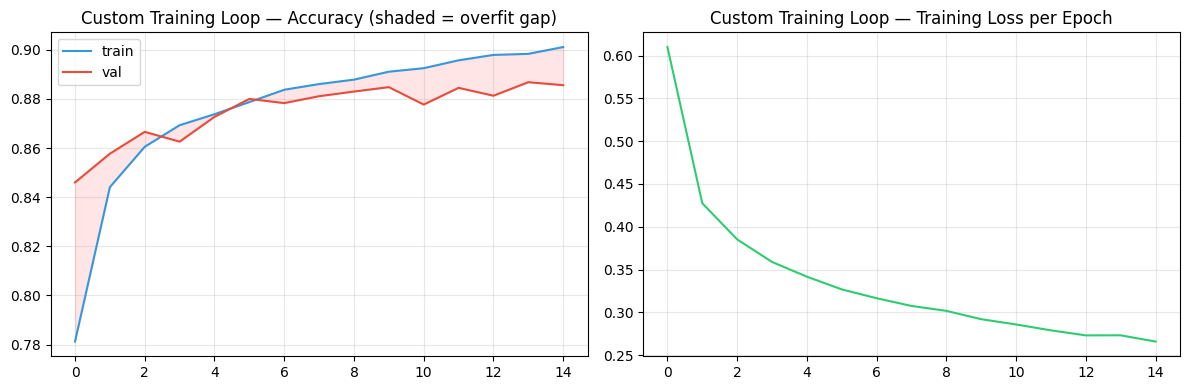

In [11]:
# Plot custom training loop results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_accs, label='train', color='#3498db')
axes[0].plot(val_accs,   label='val',   color='#e74c3c')
axes[0].fill_between(range(len(train_accs)), train_accs, val_accs, alpha=0.1, color='red')
axes[0].set_title('Custom Training Loop — Accuracy (shaded = overfit gap)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(train_losses, color='#2ecc71')
axes[1].set_title('Custom Training Loop — Training Loss per Epoch')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


Custom Training Loop (PyTorch):
 Epoch |  Train Acc |   Val Acc |         LR
─────────────────────────────────────────────
     1 |     0.7529 |    0.8326 |   7.63e-03
     2 |     0.8636 |    0.8507 |   2.19e-02
     3 |     0.8742 |    0.8560 |   3.80e-02
     4 |     0.8826 |    0.8368 |   4.86e-02
     5 |     0.8884 |    0.8599 |   4.97e-02
     6 |     0.8975 |    0.8737 |   4.75e-02
     7 |     0.9055 |    0.8636 |   4.33e-02
     8 |     0.9128 |    0.8796 |   3.75e-02
     9 |     0.9195 |    0.8710 |   3.05e-02
    10 |     0.9259 |    0.8850 |   2.31e-02
    11 |     0.9341 |    0.8842 |   1.58e-02
    12 |     0.9446 |    0.8925 |   9.39e-03
    13 |     0.9527 |    0.8974 |   4.33e-03
    14 |     0.9637 |    0.9001 |   1.10e-03
    15 |     0.9702 |    0.9006 |   2.20e-07


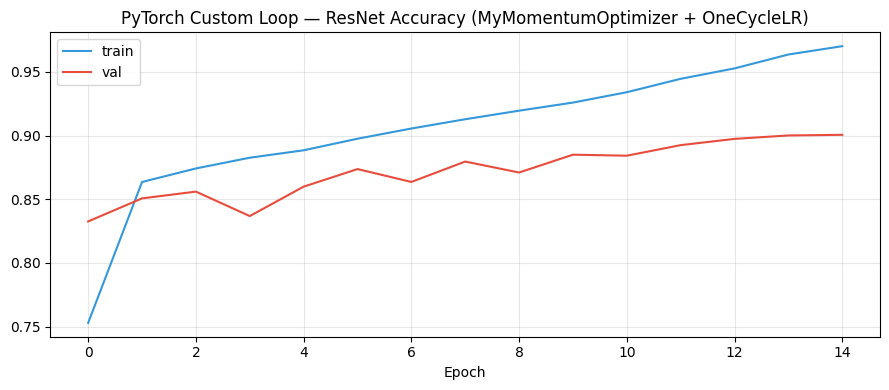

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# xi.B  Custom Training Loop — PyTorch
# ════════════════════════════════════════════════════════════════════════════
resnet_pt_train = ResNetPT(784, 10, n_blocks=4, units=128).to(DEVICE)
opt_pt    = MyMomentumOptimizerPT(resnet_pt_train.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
crit_pt   = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.OneCycleLR(
    opt_pt, max_lr=0.05, steps_per_epoch=len(train_ld_pt), epochs=15
)

# TensorBoard SummaryWriter for PyTorch training
from torch.utils.tensorboard import SummaryWriter
writer_pt = SummaryWriter('/tmp/tb_pt_custom_loop')

pt_train_accs, pt_val_accs = [], []
print('\nCustom Training Loop (PyTorch):')
print(f'{"Epoch":>6} | {"Train Acc":>10} | {"Val Acc":>9} | {"LR":>10}')
print('─'*45)

for epoch in range(1, 16):
    # ── TRAIN ──
    resnet_pt_train.train()
    correct = total = 0
    for xb, yb in train_ld_pt:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_pt.zero_grad()
        out  = resnet_pt_train(xb)
        loss = crit_pt(out, yb)
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(resnet_pt_train.parameters(), max_norm=1.0)
        opt_pt.step(); scheduler.step()
        correct += (out.argmax(1) == yb).sum().item(); total += len(yb)
    tr_acc = correct / total

    # ── EVALUATE ──
    resnet_pt_train.eval()
    with torch.no_grad():
        preds  = resnet_pt_train(X_te_pt).argmax(1)
        va_acc = (preds == y_te_pt).float().mean().item()

    current_lr = scheduler.get_last_lr()[0]
    pt_train_accs.append(tr_acc); pt_val_accs.append(va_acc)
    writer_pt.add_scalars('Accuracy', {'train': tr_acc, 'val': va_acc}, epoch)
    writer_pt.add_scalar('LR', current_lr, epoch)
    print(f'{epoch:>6} | {tr_acc:>10.4f} | {va_acc:>9.4f} | {current_lr:>10.2e}')

writer_pt.close()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pt_train_accs, label='train', color='#3498db')
ax.plot(pt_val_accs,   label='val',   color='#e74c3c')
ax.set_title('PyTorch Custom Loop — ResNet Accuracy (MyMomentumOptimizer + OneCycleLR)')
ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [13]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('═'*60)
print(' FINAL RESULTS SUMMARY')
print('═'*60)
print(f' viii) Custom Layers — best val acc      : {max(hist_viii["All custom layers"].history["val_accuracy"]):.4f}')
print(f'  ix) ResidualRegressor val acc          : {max(h_res.history["val_accuracy"]):.4f}')
print(f'       PlainDeep (no skip) val acc       : {max(h_plain.history["val_accuracy"]):.4f}')
print(f'   x) Best optimizer val acc (TF)        : {max(max(h.history["val_accuracy"]) for h in opt_histories.values()):.4f}')
print(f'      MyMomentumOptimizerPT (PT) final   : {acc_my_mom[-1]:.4f}')
print(f'  xi) Custom Loop (TF) best val acc      : {best_val_acc:.4f}')
print(f'      Custom Loop (PT) ResNet best       : {max(pt_val_accs):.4f}')
print('═'*60)

════════════════════════════════════════════════════════════
 FINAL RESULTS SUMMARY
════════════════════════════════════════════════════════════
 viii) Custom Layers — best val acc      : 0.8833
  ix) ResidualRegressor val acc          : 0.1971
       PlainDeep (no skip) val acc       : 0.8854
   x) Best optimizer val acc (TF)        : 0.8900
      MyMomentumOptimizerPT (PT) final   : 0.8727
  xi) Custom Loop (TF) best val acc      : 0.8868
      Custom Loop (PT) ResNet best       : 0.9006
════════════════════════════════════════════════════════════
